# Notebook: Clasificación HAM10000 con CoAtNet-0

## 1: Instalación de dependencias

In [1]:
# Instalación definitiva y limpieza de conflictos
%pip install -q \
    "tensorflow[and-cuda]==2.16.1" \
    tf-keras==2.16.0 \
    keras-cv==0.9.0 \
    keras-cv-attention-models \
    pandas matplotlib scikit-learn ipywidgets seaborn

# Borramos Keras 3 justo después por si TensorFlow lo ha vuelto a instalar
# %pip uninstall -y keras keras-core

Note: you may need to restart the kernel to use updated packages.


## 2: Configuración de la GPU y librerías

In [2]:
import os

# 1. Forzamos modo Legacy para CoAtNet
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# 2. Quitamos el aviso de oneDNN (para que el log sea más limpio)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

# 3. LE INDICAMOS A TENSORFLOW DÓNDE ESTÁN TUS LIBRERÍAS DE NVIDIA
# Buscamos las que instaló el comando [and-cuda] arriba
import site
for path in site.getsitepackages():
    nvidia_path = os.path.join(path, "nvidia/cudnn/lib")
    if os.path.exists(nvidia_path):
        os.environ["LD_LIBRARY_PATH"] = nvidia_path + ":" + os.environ.get("LD_LIBRARY_PATH", "")

# Añadimos la ruta del driver de Windows en WSL2
os.environ["LD_LIBRARY_PATH"] = "/usr/lib/wsl/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

import tensorflow as tf

# Comprobación de la 3080 Ti
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"🔥 ¡CONSEGUIDO! GPU lista: {gpus[0]}")
else:
    print("❌ Seguimos sin ver la GPU. Mira el error de arriba.")

2026-04-18 11:37:05.732125: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-18 11:37:06.223029: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


🔥 ¡CONSEGUIDO! GPU lista: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


2026-04-18 11:37:06.871106: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-18 11:37:06.906516: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-18 11:37:06.906562: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 3: Descarga y extracción del Dataset

Nota: debes tener descargado unzip ``sudo apt update && sudo apt install unzip -y``

In [3]:
%%bash
# 1. Definir rutas relativas al proyecto
PROJECT_ROOT=$(pwd)
DATA_DIR="$PROJECT_ROOT/datasets/ham10000"
ZIP_FILE="$DATA_DIR/ham10000-preprocessed.zip"
# Usamos la carpeta 'organized_ham10000' como señal de que ya está listo
WITNESS_DIR="$DATA_DIR/organized_ham10000"

# 2. Crear la carpeta base si no existe
mkdir -p "$DATA_DIR"

# 3. Lógica de comprobación por carpetas
if [ -d "$WITNESS_DIR" ]; then
    echo "✅ Escenario A: Las carpetas de imágenes ya existen en $WITNESS_DIR. Saltando descarga."
    
elif [ -f "$ZIP_FILE" ]; then
    echo "📦 Escenario B: ZIP encontrado pero no descomprimido. Extrayendo ahora..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
    echo "✅ Descompresión terminada y ZIP eliminado."
    
else
    echo "🌐 Escenario C: No hay datos. Iniciando descarga desde Kaggle..."
    # Descarga
    curl -L -o "$ZIP_FILE" https://www.kaggle.com/api/v1/datasets/download/rayeedaabir/ham10000-preprocessed
    
    echo "🚚 Descarga finalizada. Descomprimiendo..."
    unzip -q "$ZIP_FILE" -d "$DATA_DIR" && rm "$ZIP_FILE"
    
    echo "✅ Proceso completo. Dataset listo para usar en $WITNESS_DIR"
fi

✅ Escenario A: Las carpetas de imágenes ya existen en /home/herraiz/proyectos/TFM/datasets/ham10000/organized_ham10000. Saltando descarga.


## 4: Preparación de datos (Carga desde directorios)

In [4]:
# Parámetros de configuración
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_PATH = "datasets/ham10000/organized_ham10000"

# Cargamos el dataset de entrenamiento (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Cargamos el dataset de validación (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"✅ Clases detectadas: {class_names}")

# Optimización para la GPU (Crucial para no tener cuellos de botella)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 10015 files belonging to 7 classes.
Using 8012 files for training.


2026-04-18 11:37:07.237355: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-18 11:37:07.237440: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-18 11:37:07.237458: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-18 11:37:07.523282: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-04-18 11:37:07.523360: I external/local_xla/xla/stream_executor

Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
✅ Clases detectadas: ['Actinic Keratoses', 'Basal Cell Carcinoma', 'Benign Keratosis', 'Dermatofibroma', 'Melanocytic Nevi', 'Melanoma', 'Vascular Lesions']


## 5: Visualización de muestras

📸 Generando galería de presentación (un ejemplo por clase)...


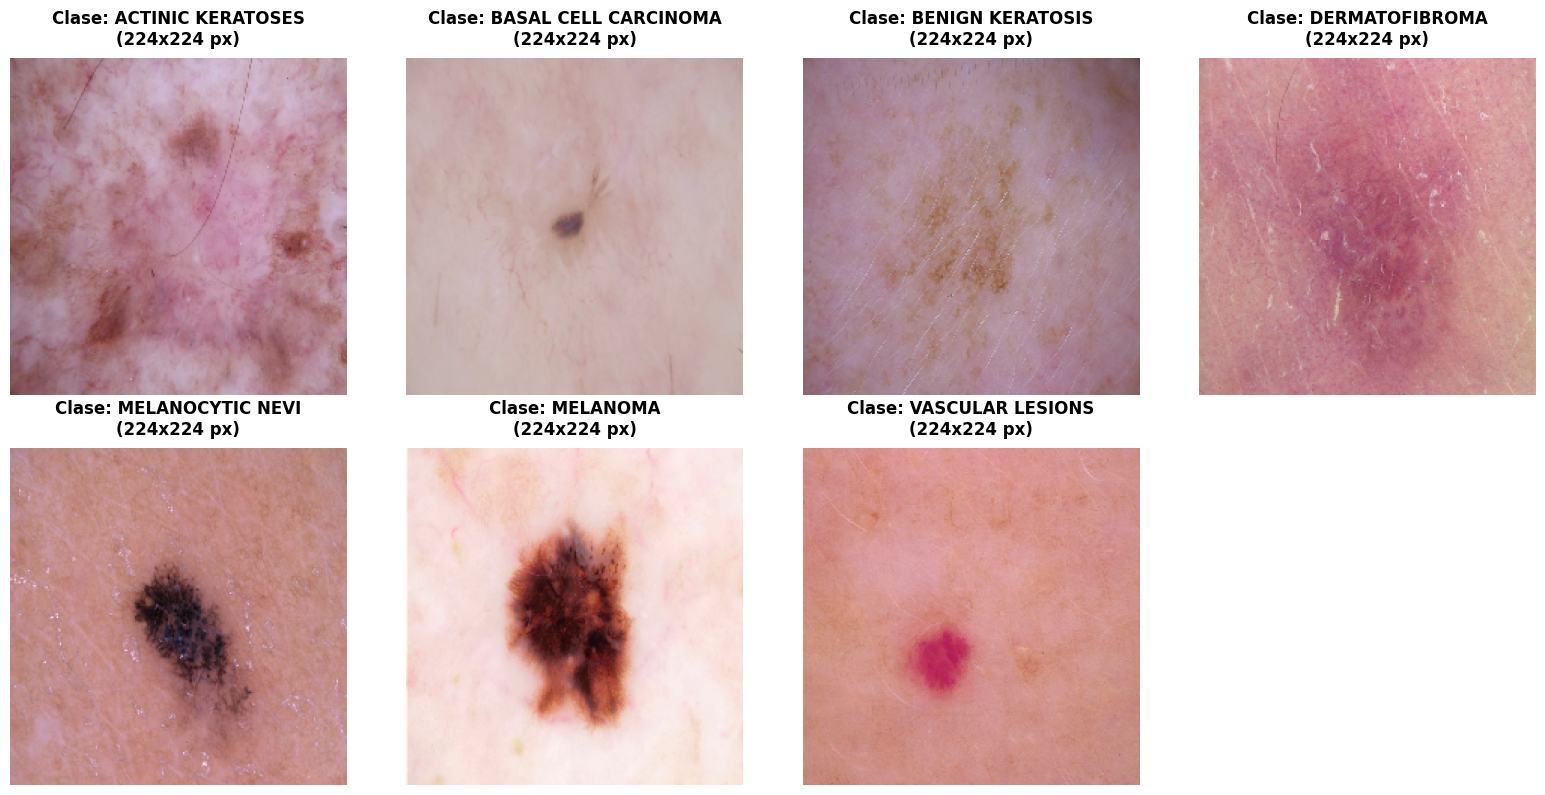

In [5]:
import matplotlib.pyplot as plt

# Configuración de la galería
plt.figure(figsize=(16, 8))
cols = 4
rows = (len(class_names) + cols - 1) // cols

print("📸 Generando galería de presentación (un ejemplo por clase)...")

for i, class_name in enumerate(sorted(class_names)):
    # Ruta a la carpeta de la clase
    class_path = os.path.join(DATA_PATH, class_name)
    # Tomamos la primera imagen que encontremos
    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)
    
    # Cargar y procesar imagen para mostrar
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")
    
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(img_array)
    
    # Título elegante con Nombre y Resolución
    plt.title(f"Clase: {class_name.upper()}\n({IMG_SIZE[0]}x{IMG_SIZE[1]} px)", 
              fontsize=12, fontweight='bold', pad=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

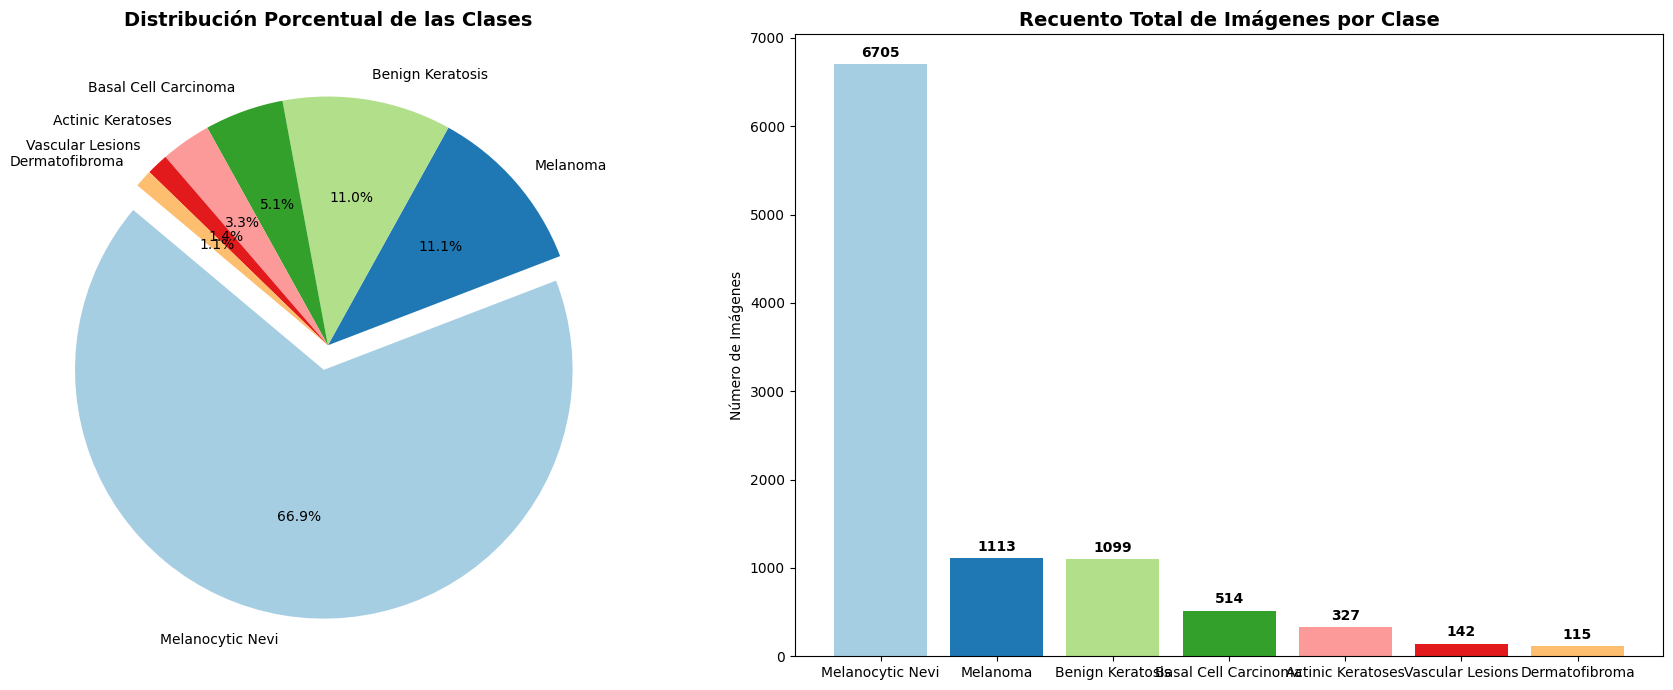


📋 Resumen Estadístico del Dataset:
                Tipo  Cantidad  Porcentaje
    Melanocytic Nevi      6705       66.95
            Melanoma      1113       11.11
    Benign Keratosis      1099       10.97
Basal Cell Carcinoma       514        5.13
   Actinic Keratoses       327        3.27
    Vascular Lesions       142        1.42
      Dermatofibroma       115        1.15


In [6]:
import pandas as pd

# 1. Contar archivos por carpeta
stats = {}
for class_name in class_names:
    class_path = os.path.join(DATA_PATH, class_name)
    stats[class_name] = len(os.listdir(class_path))

# 2. Crear DataFrame para facilitar el gráfico
df_stats = pd.DataFrame(list(stats.items()), columns=['Tipo', 'Cantidad'])
df_stats = df_stats.sort_values(by='Cantidad', ascending=False)
df_stats['Porcentaje'] = (df_stats['Cantidad'] / df_stats['Cantidad'].sum() * 100).round(2)

# 3. Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de Tarta
colors = plt.cm.Paired(range(len(class_names)))
wedges, texts, autotexts = ax1.pie(df_stats['Cantidad'], labels=df_stats['Tipo'], 
                                   autopct='%1.1f%%', startangle=140, colors=colors,
                                   explode=[0.1 if i == 0 else 0 for i in range(len(df_stats))])
ax1.set_title("Distribución Porcentual de las Clases", fontsize=14, fontweight='bold')

# Gráfico de Barras
bars = ax2.bar(df_stats['Tipo'], df_stats['Cantidad'], color=colors)
ax2.set_title("Recuento Total de Imágenes por Clase", fontsize=14, fontweight='bold')
ax2.set_ylabel("Número de Imágenes")

# Añadir etiquetas de cantidad sobre las barras
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 50, yval, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Mostrar tabla resumen
print("\n📋 Resumen Estadístico del Dataset:")
print(df_stats.to_string(index=False))

## 6: Pipeline de entrenamiento con CoAtNet-0

In [7]:
from keras_cv_attention_models import coatnet

# 1. Definimos la arquitectura CoAtNet-0
# pretrained="imagenet" es clave para el Transfer Learning (el modelo ya sabe ver)
model = coatnet.CoAtNet0(
    input_shape=(224, 224, 3),
    num_classes=len(class_names), # Las 7 clases detectadas en la Celda 4
    pretrained="imagenet"
)

# 2. Compilación del modelo
# Usamos un learning rate bajo (1e-4) para no destruir el conocimiento previo de ImageNet
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Modelo CoAtNet-0 cargado y compilado con éxito.")
model.summary()

>>>> Load pretrained from: /home/herraiz/.keras/models/coatnet0_224_imagenet.h5
✅ Modelo CoAtNet-0 cargado y compilado con éxito.
Model: "coatnet0"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 stem_1_pad (ZeroPadding2D)  (None, 226, 226, 3)          0         ['input_1[0][0]']             
                                                                                                  
 stem_1_conv (Conv2D)        (None, 112, 112, 64)         1728      ['stem_1_pad[0][0]']          
                                                                                                  
 stem_1_bn (BatchNormalizat  (None, 112, 112, 64)         25

## 7: Entrenamiento (Prueba rápida)

In [8]:
import numpy as np

# --- CONFIGURACIÓN DE FLUJO ---
SKIP_TRAINING = True  # True: Carga el modelo si existe | False: Entrena de cero
checkpoint_path = "models/best_coatnet_v1.h5"

# 1. Lógica de Entrenamiento / Carga
model_exists = os.path.exists(checkpoint_path)
should_train = True

if SKIP_TRAINING and model_exists:
    print(f"📦 Cargando modelo guardado desde: {checkpoint_path}")
    model.load_weights(checkpoint_path)
    should_train = False
    history = None
else:
    if SKIP_TRAINING and not model_exists:
        print("⚠️ Aviso: SKIP_TRAINING es True pero no hay modelo. Entrenando...")
    else:
        print("🔥 Iniciando entrenamiento en la RTX 3080 Ti...")
    
    os.makedirs("models", exist_ok=True)
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=[checkpoint_callback]
    )

# 2. PREDICCIONES DE ENTRENAMIENTO (Lo que estaba en la Celda 11)
# Esto se ejecuta siempre para tener las variables listas para las gráficas
print("\n🏋️ Generando predicciones sobre el set de ENTRENAMIENTO para métricas...")
y_true_train = []
y_pred_train = []

for images, labels in train_ds:
    # Usamos la GPU para predecir rápido
    predictions = model.predict(images, verbose=0)
    y_true_train.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_train.extend(np.argmax(predictions, axis=1))

y_true_train = np.array(y_true_train)
y_pred_train = np.array(y_pred_train)

print(f"✅ Análisis de entrenamiento completado ({len(y_true_train)} imágenes).")

📦 Cargando modelo guardado desde: models/best_coatnet_v1.h5

🏋️ Generando predicciones sobre el set de ENTRENAMIENTO para métricas...


2026-04-18 11:37:21.203319: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


✅ Análisis de entrenamiento completado (8012 imágenes).


2026-04-18 11:37:49.663979: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 8: Predicciones (Preparación de datos)
En esta celda extraemos las etiquetas reales y generamos las predicciones del modelo sobre el set de validación.

In [9]:
import numpy as np

print("🔮 Generando predicciones sobre el set de VALIDACIÓN...")

y_true_val = []
y_pred_val = []

# Recorremos el dataset de validación
for images, labels in val_ds:
    # Predecimos con la GPU
    predictions = model.predict(images, verbose=0)
    
    # Guardamos etiquetas reales y predicciones del modelo
    y_true_val.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_val.extend(np.argmax(predictions, axis=1))

y_true_val = np.array(y_true_val)
y_pred_val = np.array(y_pred_val)

print(f"✅ Análisis de validación completado ({len(y_true_val)} imágenes).")

🔮 Generando predicciones sobre el set de VALIDACIÓN...
✅ Análisis de validación completado (2003 imágenes).


2026-04-18 11:37:56.247883: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 9: Métricas Globales y por Clase

Aquí verás el rendimiento del entrenamiento (si lo hubo) y el reporte detallado (Precisión, Recall, F1-Score) por cada tipo de lesión.

In [10]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Accuracy Global
acc_train = accuracy_score(y_true_train, y_pred_train)
acc_val = accuracy_score(y_true_val, y_pred_val)

print("="*60)
print(f"📈 RENDIMIENTO GLOBAL")
print(f"   - Accuracy Entrenamiento: {acc_train:.4f}")
print(f"   - Accuracy Validación:    {acc_val:.4f}")
print("="*60)

# 2. Reporte Detallado de Validación (El más importante)
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):")
print(classification_report(y_true_val, y_pred_val, target_names=class_names))

# 3. Reporte Detallado de Entrenamiento (Opcional, para comparar)
print("\n📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):")
print(classification_report(y_true_train, y_pred_train, target_names=class_names))

📈 RENDIMIENTO GLOBAL
   - Accuracy Entrenamiento: 0.9890
   - Accuracy Validación:    0.8732

📋 REPORTE DETALLADO POR CLASE (SET DE VALIDACIÓN):
                      precision    recall  f1-score   support

   Actinic Keratoses       0.72      0.44      0.54        64
Basal Cell Carcinoma       0.65      0.84      0.73        99
    Benign Keratosis       0.77      0.70      0.73       215
      Dermatofibroma       0.82      0.61      0.70        23
    Melanocytic Nevi       0.93      0.96      0.94      1362
            Melanoma       0.74      0.69      0.71       210
    Vascular Lesions       1.00      0.67      0.80        30

            accuracy                           0.87      2003
           macro avg       0.80      0.70      0.74      2003
        weighted avg       0.87      0.87      0.87      2003


📋 REPORTE DETALLADO POR CLASE (SET DE ENTRENAMIENTO):
                      precision    recall  f1-score   support

   Actinic Keratoses       0.99      0.91      0.95 

## 10: Matriz de Confusión

Esta es la gráfica visual definitiva para ver dónde se "equivoca" el modelo (por ejemplo, si confunde Melanoma con Nevus).

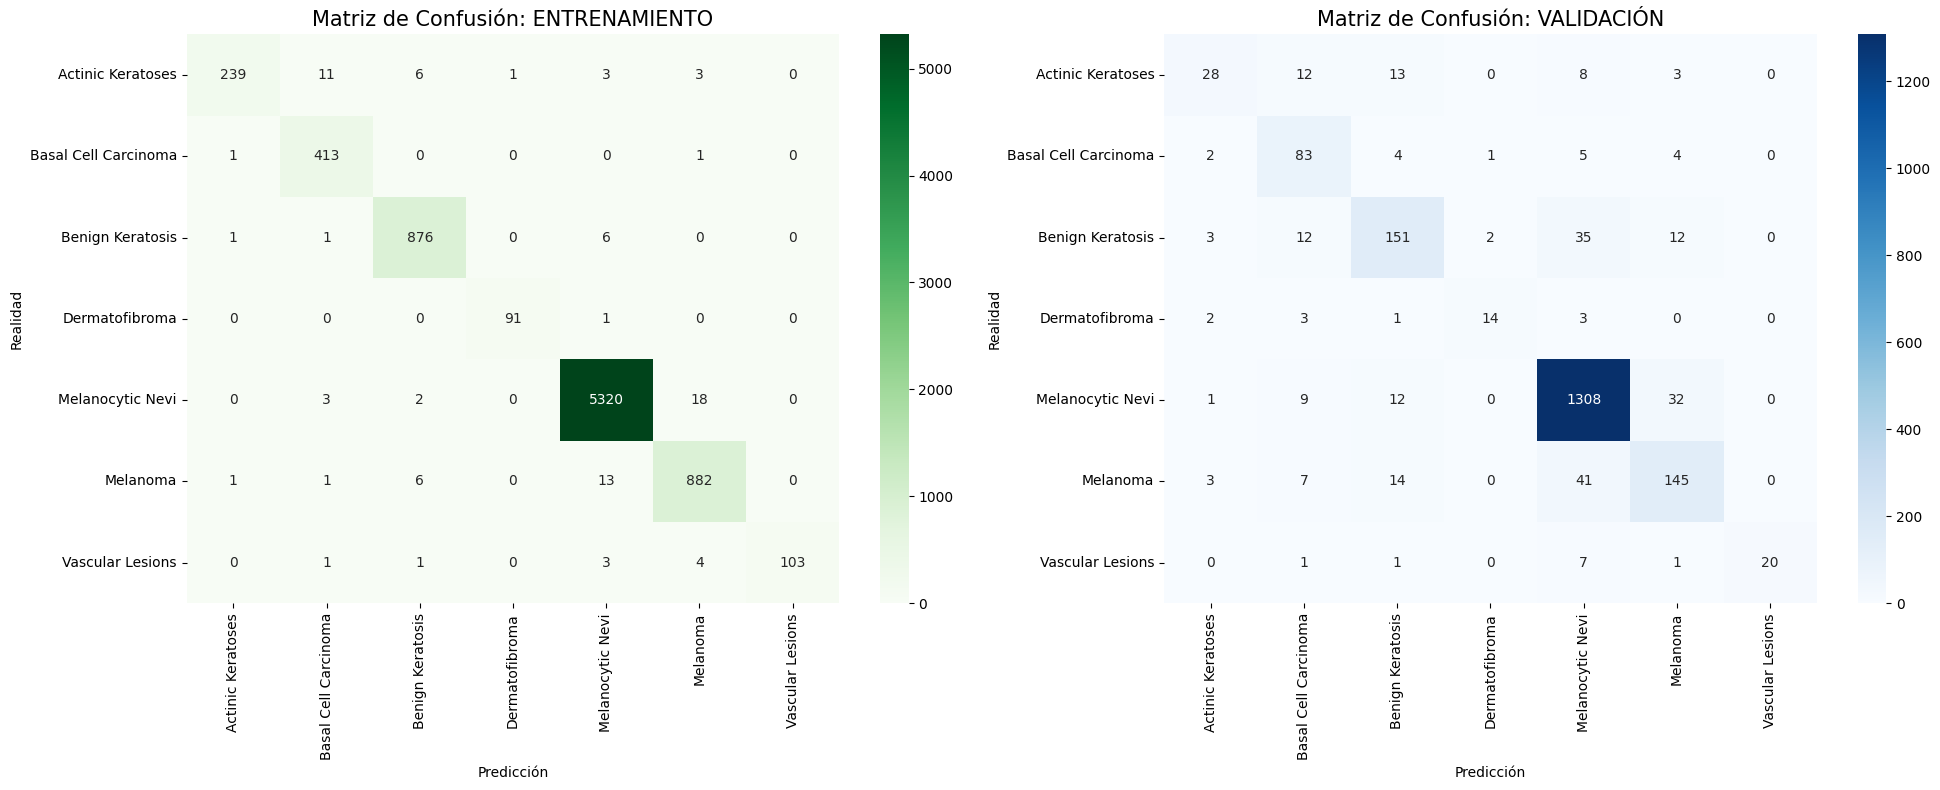

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculamos las matrices
cm_train = confusion_matrix(y_true_train, y_pred_train)
cm_val = confusion_matrix(y_true_val, y_pred_val)

# Configuramos el gráfico
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Matriz de Entrenamiento (Verde)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens', ax=ax[0],
            xticklabels=class_names, yticklabels=class_names)
ax[0].set_title('Matriz de Confusión: ENTRENAMIENTO', fontsize=15)
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Realidad')

# Matriz de Validación (Azul)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax[1],
            xticklabels=class_names, yticklabels=class_names)
ax[1].set_title('Matriz de Confusión: VALIDACIÓN', fontsize=15)
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Realidad')

plt.tight_layout()
plt.show()